# Pairwise Ranking Model for Best Fundus Image Selection

このノートブックでは、ヒトの専門家が選択したベスト画像と同じ画像をAIが選択できるよう、Pairwise Rankingモデルを学習します。

## アプローチ
- **入力**: 各動画からルールベースAIで上位100枚をフィルタリング
- **学習データ**: 正例（ヒトTop5）× 負例（残り95枚）のペア
- **モデル**: Feature-based MLP（15次元 → 64 → 32 → 16 → 1）
- **損失関数**: Margin Ranking Loss (margin=1.0)
- **評価**: Leave-One-Video-Out 22-fold CV

## 目標
- 現状: ルールベースAI → 54.5% 画像一致率
- 目標: 学習ベースRanker → 65-75% 画像一致率

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 日本語フォント設定
plt.rcParams['font.family'] = 'MS Gothic'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.1+cu121
CUDA available: True
CUDA device: Quadro RTX 5000


## 1. 設定クラス

In [2]:
@dataclass
class Config:
    """Configuration for pairwise ranking model training."""

    # Paths
    base_dir: Path = Path(r'C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation')
    
    # Feature columns
    feature_columns: List[str] = field(default_factory=lambda: [
        'retina_ratio', 'retina_area', 'disc_detected',
        'disc_edge_coverage_ratio', 'disc_area_ratio', 'disc_center_dist_ratio',
        'disc_pos_ok', 'mbss_L_multi', 'mbss_HF_ratio', 'mbss_Spec_centroid',
        'mbss_Grad_p90', 'mbss_score', 'disc_core_score', 'disc_ring_score', 'S_mean',
    ])

    # Rule-based score weights (for Top 100 filtering)
    rule_based_weights: dict = field(default_factory=lambda: {
        'retina_ratio': 0.4, 'mbss_Grad_p90': 0.4, 'mbss_score': 0.2,
    })

    # Data settings
    top_k_candidates: int = 100
    num_negatives_per_positive: int = 10
    hard_negative_ratio: float = 0.5

    # Model architecture
    input_dim: int = 15
    hidden_dims: List[int] = field(default_factory=lambda: [64, 32, 16])
    dropout: float = 0.3

    # Training settings
    learning_rate: float = 1e-3
    margin: float = 1.0
    batch_size: int = 64
    num_epochs: int = 100
    early_stopping_patience: int = 10
    weight_decay: float = 1e-4

    # Evaluation
    top_k_eval: int = 5
    seed: int = 42

    def __post_init__(self):
        self.results_dir = self.base_dir / 'validation_results'
        self.merged_csv_path = self.results_dir / 'merged_with_disc.csv'
        self.output_dir = self.base_dir / 'ranking_model' / 'outputs'

config = Config()
print(f"Base directory: {config.base_dir}")
print(f"Model: {config.input_dim} -> {config.hidden_dims} -> 1")
print(f"Epochs: {config.num_epochs}, Early stopping: {config.early_stopping_patience}")

Base directory: C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation
Model: 15 -> [64, 32, 16] -> 1
Epochs: 100, Early stopping: 10


## 2. データセットクラス

In [3]:
class ROPRankingDataset:
    """Dataset class for ROP best image ranking."""

    def __init__(self, config: Config):
        self.config = config
        self.df = None
        self.human_selections = {}
        self.case_ids = []
        self.scalers = {}

    def load_data(self) -> pd.DataFrame:
        """Load and merge feature data with human selections."""
        self.df = pd.read_csv(self.config.merged_csv_path)
        self._load_human_selections()
        self._mark_human_selections()
        self.case_ids = sorted(self.df['case_id'].unique().tolist())
        print(f"Loaded {len(self.df)} images from {len(self.case_ids)} videos")
        print(f"Human-selected images: {self.df['is_human_top'].sum()}")
        return self.df

    def _load_human_selections(self):
        """Load human selections from Excel file."""
        xlsx_path = self.config.results_dir / 'ベストショット一致率20260104.xlsx'
        if xlsx_path.exists():
            df_excel = pd.read_excel(xlsx_path, sheet_name=0)
            for case_id in df_excel['動画番号'].unique():
                case_data = df_excel[df_excel['動画番号'] == case_id]
                yf_images, hk_images = [], []
                for _, row in case_data.iterrows():
                    if pd.notna(row.get('YF')):
                        yf_images.append(f'IMG_{case_id}_{int(row["YF"]):04d}.jpg')
                    if pd.notna(row.get('HK')):
                        hk_images.append(f'IMG_{case_id}_{int(row["HK"]):04d}.jpg')
                self.human_selections[case_id] = {
                    'YF': yf_images[:5], 'HK': hk_images[:5],
                    'all': list(set(yf_images[:5] + hk_images[:5]))
                }
        elif 'is_human_top' in self.df.columns:
            for case_id in self.df['case_id'].unique():
                case_df = self.df[(self.df['case_id'] == case_id) & (self.df['is_human_top'] == True)]
                self.human_selections[case_id] = {'all': case_df['image_name'].tolist()}

    def _mark_human_selections(self):
        """Mark human-selected images in the dataframe."""
        if 'is_human_top' not in self.df.columns:
            self.df['is_human_top'] = False
        for case_id, selections in self.human_selections.items():
            all_selected = selections.get('all', [])
            mask = (self.df['case_id'] == case_id) & (self.df['image_name'].isin(all_selected))
            self.df.loc[mask, 'is_human_top'] = True

    def compute_rule_based_score(self, df: pd.DataFrame) -> pd.Series:
        """Compute rule-based score for Top 100 filtering."""
        weights = self.config.rule_based_weights
        score = pd.Series(0.0, index=df.index)
        for col, weight in weights.items():
            if col in df.columns:
                score += weight * df[col].fillna(0)
        return score

    def get_top_k_candidates(self, case_id: int, k: int = None) -> pd.DataFrame:
        """Get top-k candidates for a video using rule-based score."""
        k = k or self.config.top_k_candidates
        case_df = self.df[self.df['case_id'] == case_id].copy()
        
        # Basic filter
        filtered = case_df[(case_df['disc_detected'] == True) & (case_df['retina_ratio'] > 0)].copy()
        if len(filtered) == 0:
            filtered = case_df[case_df['retina_ratio'] > 0].copy()
        if len(filtered) == 0:
            return case_df.head(k)

        # Preprocess features
        for col in self.config.feature_columns:
            if col in ['disc_detected', 'disc_pos_ok']:
                filtered[col] = filtered[col].fillna(False).astype(float)
            elif col in filtered.columns:
                median_val = filtered[col].median()
                filtered[col] = filtered[col].fillna(median_val if pd.notna(median_val) else 0)
            else:
                filtered[col] = 0.0

        # Normalize
        numeric_cols = [c for c in self.config.feature_columns if c not in ['disc_detected', 'disc_pos_ok'] and c in filtered.columns]
        if numeric_cols:
            scaler = MinMaxScaler()
            filtered[numeric_cols] = scaler.fit_transform(filtered[numeric_cols].fillna(0))

        filtered['rule_score'] = self.compute_rule_based_score(filtered)
        return filtered.nlargest(min(k, len(filtered)), 'rule_score')

    def _get_features(self, row: pd.Series) -> np.ndarray:
        """Extract feature vector from a row."""
        features = []
        for col in self.config.feature_columns:
            val = row.get(col, 0.0)
            features.append(float(val) if pd.notna(val) else 0.0)
        return np.array(features, dtype=np.float32)

    def generate_pairwise_samples(self, case_ids: List[int] = None) -> Tuple[List[Dict], pd.DataFrame]:
        """Generate pairwise training samples."""
        case_ids = case_ids or self.case_ids
        all_pairs, all_candidates = [], []

        for case_id in case_ids:
            candidates = self.get_top_k_candidates(case_id)
            all_candidates.append(candidates)

            positives = candidates[candidates['is_human_top'] == True]
            negatives = candidates[candidates['is_human_top'] == False]

            if len(positives) == 0 or len(negatives) == 0:
                continue

            num_negs = self.config.num_negatives_per_positive
            hard_ratio = self.config.hard_negative_ratio

            for _, pos_row in positives.iterrows():
                num_hard = int(num_negs * hard_ratio)
                num_random = num_negs - num_hard

                hard_negs = negatives.nlargest(min(len(negatives) // 2, num_hard * 2), 'rule_score')
                if len(hard_negs) > num_hard:
                    hard_negs = hard_negs.sample(num_hard)

                remaining = negatives[~negatives.index.isin(hard_negs.index)]
                random_negs = remaining.sample(min(num_random, len(remaining))) if len(remaining) > 0 else pd.DataFrame()

                selected_negs = pd.concat([hard_negs, random_negs])

                for _, neg_row in selected_negs.iterrows():
                    all_pairs.append({
                        'case_id': case_id,
                        'pos_features': torch.tensor(self._get_features(pos_row), dtype=torch.float32),
                        'neg_features': torch.tensor(self._get_features(neg_row), dtype=torch.float32),
                    })

        all_candidates_df = pd.concat(all_candidates, ignore_index=True) if all_candidates else pd.DataFrame()
        print(f"Generated {len(all_pairs)} pairwise samples from {len(case_ids)} videos")
        return all_pairs, all_candidates_df

## 3. モデル定義

In [4]:
class PairwiseRanker(nn.Module):
    """MLP-based pairwise ranking model."""

    def __init__(self, input_dim: int = 15, hidden_dims: List[int] = [64, 32, 16], dropout: float = 0.3):
        super().__init__()
        layers = [nn.BatchNorm1d(input_dim)]
        prev_dim = input_dim
        for i, hidden_dim in enumerate(hidden_dims):
            layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            if i < len(hidden_dims) - 1:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)

    def compute_pairwise_loss(self, pos_features: torch.Tensor, neg_features: torch.Tensor, margin: float = 1.0) -> torch.Tensor:
        pos_scores = self.forward(pos_features)
        neg_scores = self.forward(neg_features)
        return F.margin_ranking_loss(pos_scores, neg_scores, target=torch.ones_like(pos_scores), margin=margin)


class PairwiseBatchDataset(Dataset):
    """PyTorch Dataset for pairwise samples."""
    def __init__(self, pairs: List[Dict]):
        self.pairs = pairs

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {'pos_features': self.pairs[idx]['pos_features'], 'neg_features': self.pairs[idx]['neg_features']}

## 4. 学習クラス

In [5]:
class EarlyStopping:
    """Early stopping to prevent overfitting."""
    def __init__(self, patience: int = 10, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_value = None

    def __call__(self, value: float) -> bool:
        if self.best_value is None:
            self.best_value = value
            return False
        if value < self.best_value - self.min_delta:
            self.best_value = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False


class Trainer:
    """Trainer class for Pairwise Ranker."""

    def __init__(self, model: PairwiseRanker, config: Config, device: str = None):
        self.config = config
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        self.optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=5)
        self.history = {'train_loss': [], 'train_acc': [], 'lr': []}

    def train_epoch(self, train_loader: DataLoader, margin: float) -> Tuple[float, float]:
        self.model.train()
        total_loss, total_correct, total_samples = 0.0, 0, 0

        for batch in train_loader:
            pos_features = batch['pos_features'].to(self.device)
            neg_features = batch['neg_features'].to(self.device)

            self.optimizer.zero_grad()
            loss = self.model.compute_pairwise_loss(pos_features, neg_features, margin)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * pos_features.size(0)
            with torch.no_grad():
                pos_scores = self.model(pos_features)
                neg_scores = self.model(neg_features)
                total_correct += (pos_scores > neg_scores).sum().item()
                total_samples += pos_features.size(0)

        return total_loss / total_samples, total_correct / total_samples

    def fit(self, train_loader: DataLoader, num_epochs: int = None, verbose: bool = True) -> Dict:
        num_epochs = num_epochs or self.config.num_epochs
        early_stopper = EarlyStopping(patience=self.config.early_stopping_patience)
        best_loss, best_state = float('inf'), None

        epoch_iter = tqdm(range(num_epochs), desc='Training') if verbose else range(num_epochs)

        for epoch in epoch_iter:
            train_loss, train_acc = self.train_epoch(train_loader, self.config.margin)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)

            self.scheduler.step(train_loss)
            self.history['lr'].append(self.optimizer.param_groups[0]['lr'])

            if train_loss < best_loss:
                best_loss = train_loss
                best_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

            if early_stopper(train_loss):
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                break

            if verbose and hasattr(epoch_iter, 'set_description'):
                epoch_iter.set_description(f"Loss={train_loss:.4f}, Acc={train_acc:.4f}")

        if best_state:
            self.model.load_state_dict(best_state)

        return self.history

    def save_checkpoint(self, path: Path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        torch.save({'model_state_dict': self.model.state_dict(), 'history': self.history}, path)
        print(f"Checkpoint saved to {path}")

## 5. 評価クラス

In [6]:
class Evaluator:
    """Evaluator class for ranking model."""

    def __init__(self, model: PairwiseRanker, config: Config, device: str = None):
        self.model = model
        self.config = config
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        self.model.eval()

    def _extract_features(self, df: pd.DataFrame) -> np.ndarray:
        features = []
        for col in self.config.feature_columns:
            if col in df.columns:
                values = df[col].values
                if col in ['disc_detected', 'disc_pos_ok']:
                    values = np.where(pd.isna(values), 0, values).astype(float)
                else:
                    median_val = np.nanmedian(values) if np.any(~np.isnan(values.astype(float))) else 0
                    values = np.where(pd.isna(values), median_val, values)
            else:
                values = np.zeros(len(df))
            features.append(values)
        return np.stack(features, axis=1).astype(np.float32)

    def predict_scores(self, df: pd.DataFrame) -> np.ndarray:
        features = self._extract_features(df)
        features_tensor = torch.tensor(features, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            scores = self.model(features_tensor).cpu().numpy()
        return scores

    def evaluate_case(self, df: pd.DataFrame, case_id: int, k: int = 5) -> Dict:
        scores = self.predict_scores(df)
        df_eval = df.copy()
        df_eval['predicted_score'] = scores

        ai_top_k = df_eval.nlargest(k, 'predicted_score')['image_name'].tolist()
        human_top = df_eval[df_eval['is_human_top'] == True]['image_name'].tolist()
        matches = len(set(ai_top_k) & set(human_top))

        # NDCG@k
        sorted_df = df_eval.sort_values('predicted_score', ascending=False)
        relevance = sorted_df['is_human_top'].astype(int).values[:k]
        dcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(relevance))
        ideal_relevance = sorted(df_eval['is_human_top'].astype(int).values, reverse=True)[:k]
        idcg = sum((2 ** rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_relevance))
        ndcg = dcg / idcg if idcg > 0 else 0.0

        # MRR
        mrr = 0.0
        for rank, row in enumerate(sorted_df.itertuples(), 1):
            if row.is_human_top:
                mrr = 1.0 / rank
                break

        return {
            'case_id': case_id,
            'top5_precision': matches / k,
            'top5_recall': matches / len(human_top) if human_top else 0,
            'video_match': 1 if matches > 0 else 0,
            'ndcg_at_5': ndcg,
            'mrr': mrr,
            'ai_top_k': ai_top_k,
            'human_top': human_top,
            'num_matches': matches,
        }

## 6. LOVO CV関数

In [7]:
def run_lovo_cv(dataset: ROPRankingDataset, config: Config, num_folds: int = None, num_epochs: int = None, verbose: bool = True) -> Dict:
    """
    Run Leave-One-Video-Out cross-validation.
    
    Args:
        dataset: ROPRankingDataset instance
        config: Config instance
        num_folds: Number of folds (None = all)
        num_epochs: Override epochs (None = use config)
        verbose: Print progress
    """
    results = {'case_id': [], 'top5_precision': [], 'top5_recall': [], 'video_match': [], 'ndcg_at_5': [], 'mrr': [], 'pairwise_acc': []}

    case_ids_to_eval = dataset.case_ids[:num_folds] if num_folds else dataset.case_ids
    epochs = num_epochs or config.num_epochs

    if verbose:
        print(f"Running LOVO CV: {len(case_ids_to_eval)} folds, {epochs} epochs each")

    case_iter = tqdm(case_ids_to_eval, desc='LOVO CV') if verbose else case_ids_to_eval

    for test_case_id in case_iter:
        # Train/test split
        train_case_ids = [cid for cid in dataset.case_ids if cid != test_case_id]
        train_pairs, _ = dataset.generate_pairwise_samples(train_case_ids)
        test_df = dataset.get_top_k_candidates(test_case_id)

        train_dataset = PairwiseBatchDataset(train_pairs)
        train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

        # Train
        model = PairwiseRanker(config.input_dim, config.hidden_dims, config.dropout)
        trainer = Trainer(model, config)
        trainer.fit(train_loader, num_epochs=epochs, verbose=False)

        # Evaluate
        evaluator = Evaluator(model, config)
        metrics = evaluator.evaluate_case(test_df, test_case_id)

        results['case_id'].append(test_case_id)
        for key in ['top5_precision', 'top5_recall', 'video_match', 'ndcg_at_5', 'mrr']:
            results[key].append(metrics.get(key, 0))
        results['pairwise_acc'].append(0)  # Placeholder

        if verbose and hasattr(case_iter, 'set_description'):
            case_iter.set_description(f"Case {test_case_id}: Prec={metrics['top5_precision']:.2f}")

    if verbose:
        print("\n" + "=" * 60)
        print(f"LOVO CV Results ({len(case_ids_to_eval)} folds)")
        print("=" * 60)
        print(f"Mean Top-5 Precision: {np.mean(results['top5_precision']):.4f}")
        print(f"Mean Top-5 Recall: {np.mean(results['top5_recall']):.4f}")
        print(f"Video Match Rate: {np.mean(results['video_match']):.4f}")
        print(f"Mean NDCG@5: {np.mean(results['ndcg_at_5']):.4f}")
        print(f"Mean MRR: {np.mean(results['mrr']):.4f}")

    return results


def run_pilot_test(dataset: ROPRankingDataset, config: Config, num_folds: int = 1, num_epochs: int = 20, verbose: bool = True) -> Dict:
    """Quick pilot test with reduced epochs and folds."""
    if verbose:
        print("=" * 60)
        print(f"PILOT TEST: {num_folds} fold(s), {num_epochs} epochs")
        print("=" * 60)
    return run_lovo_cv(dataset, config, num_folds=num_folds, num_epochs=num_epochs, verbose=verbose)

---
# 実行セクション
---

## 7. データ読み込み

In [8]:
# データセット初期化・読み込み
dataset = ROPRankingDataset(config)
df = dataset.load_data()

print(f"\nDataset shape: {df.shape}")
print(f"Case IDs: {dataset.case_ids}")
print(f"Number of cases: {len(dataset.case_ids)}")

Loaded 6689 images from 22 videos
Human-selected images: 138

Dataset shape: (6689, 27)
Case IDs: [1227, 1363, 1376, 1601, 1632, 1703, 1732, 1891, 1966, 2024, 2026, 2028, 2116, 2168, 2232, 2289, 2290, 2356, 2358, 2376, 2403, 2431]
Number of cases: 22


In [9]:
# Top-100カバレッジの確認
print("Human selections coverage in Top 100:")
coverage_list = []
for case_id in dataset.case_ids:
    top_100 = dataset.get_top_k_candidates(case_id, k=100)
    n_human_in_top100 = top_100['is_human_top'].sum()
    n_human_total = df[(df['case_id'] == case_id) & (df['is_human_top'] == True)].shape[0]
    coverage = n_human_in_top100 / n_human_total if n_human_total > 0 else 0
    coverage_list.append(coverage)
    print(f"  Case {case_id}: {n_human_in_top100}/{n_human_total} ({coverage*100:.1f}%)")

print(f"\nMean coverage: {np.mean(coverage_list)*100:.1f}%")

Human selections coverage in Top 100:
  Case 1227: 6/6 (100.0%)
  Case 1363: 6/6 (100.0%)
  Case 1376: 6/6 (100.0%)
  Case 1601: 5/7 (71.4%)
  Case 1632: 6/6 (100.0%)
  Case 1703: 7/7 (100.0%)
  Case 1732: 0/0 (0.0%)
  Case 1891: 8/8 (100.0%)
  Case 1966: 5/5 (100.0%)
  Case 2024: 5/5 (100.0%)
  Case 2026: 6/6 (100.0%)
  Case 2028: 7/7 (100.0%)
  Case 2116: 7/7 (100.0%)
  Case 2168: 6/6 (100.0%)
  Case 2232: 7/7 (100.0%)
  Case 2289: 2/9 (22.2%)
  Case 2290: 7/8 (87.5%)
  Case 2356: 7/7 (100.0%)
  Case 2358: 6/6 (100.0%)
  Case 2376: 6/6 (100.0%)
  Case 2403: 6/6 (100.0%)
  Case 2431: 7/7 (100.0%)

Mean coverage: 90.1%


## 8. パイロットテスト（1-Fold）

フルCVの前に動作確認

In [10]:
# パイロットテスト（1フォールド、20エポック）
pilot_results = run_pilot_test(dataset, config, num_folds=1, num_epochs=20, verbose=True)

print("\n" + "=" * 60)
print("Pilot Test Summary")
print("=" * 60)
print(f"Top-5 Precision: {pilot_results['top5_precision'][0]:.4f}")
print(f"Video Match: {pilot_results['video_match'][0]}")
print(f"Baseline: 0.545")
print()
print("パイロットテストが成功したら、次のセルでフルCVを実行してください。")

PILOT TEST: 1 fold(s), 20 epochs
Running LOVO CV: 1 folds, 20 epochs each


LOVO CV:   0%|          | 0/1 [00:00<?, ?it/s]

Generated 1220 pairwise samples from 21 videos


Case 1227: Prec=0.00: 100%|██████████| 1/1 [00:08<00:00,  8.13s/it]


LOVO CV Results (1 folds)
Mean Top-5 Precision: 0.0000
Mean Top-5 Recall: 0.0000
Video Match Rate: 0.0000
Mean NDCG@5: 0.0000
Mean MRR: 0.0294

Pilot Test Summary
Top-5 Precision: 0.0000
Video Match: 0
Baseline: 0.545

パイロットテストが成功したら、次のセルでフルCVを実行してください。


## 9. フルLOVO CV（22フォールド）

**注意**: 全22フォールドを実行するため時間がかかります

In [11]:
# フルLOVO CV実行
# num_folds=5 などで部分実行も可能

cv_results = run_lovo_cv(dataset, config, num_folds=None, verbose=True)  # 全フォールド

Running LOVO CV: 22 folds, 100 epochs each


LOVO CV:   0%|          | 0/22 [00:00<?, ?it/s]

Generated 1220 pairwise samples from 21 videos


Case 1227: Prec=0.00:   5%|▍         | 1/22 [00:18<06:36, 18.86s/it]

Generated 1220 pairwise samples from 21 videos


...

Generated 1220 pairwise samples from 21 videos


Case 2403: Prec=0.00:  95%|█████████▌| 21/22 [05:12<00:13, 13.78s/it]

Generated 1210 pairwise samples from 21 videos


Case 2431: Prec=0.20: 100%|██████████| 22/22 [05:26<00:00, 14.85s/it]


LOVO CV Results (22 folds)
Mean Top-5 Precision: 0.1909
Mean Top-5 Recall: 0.1758
Video Match Rate: 0.5000
Mean NDCG@5: 0.2121
Mean MRR: 0.3741


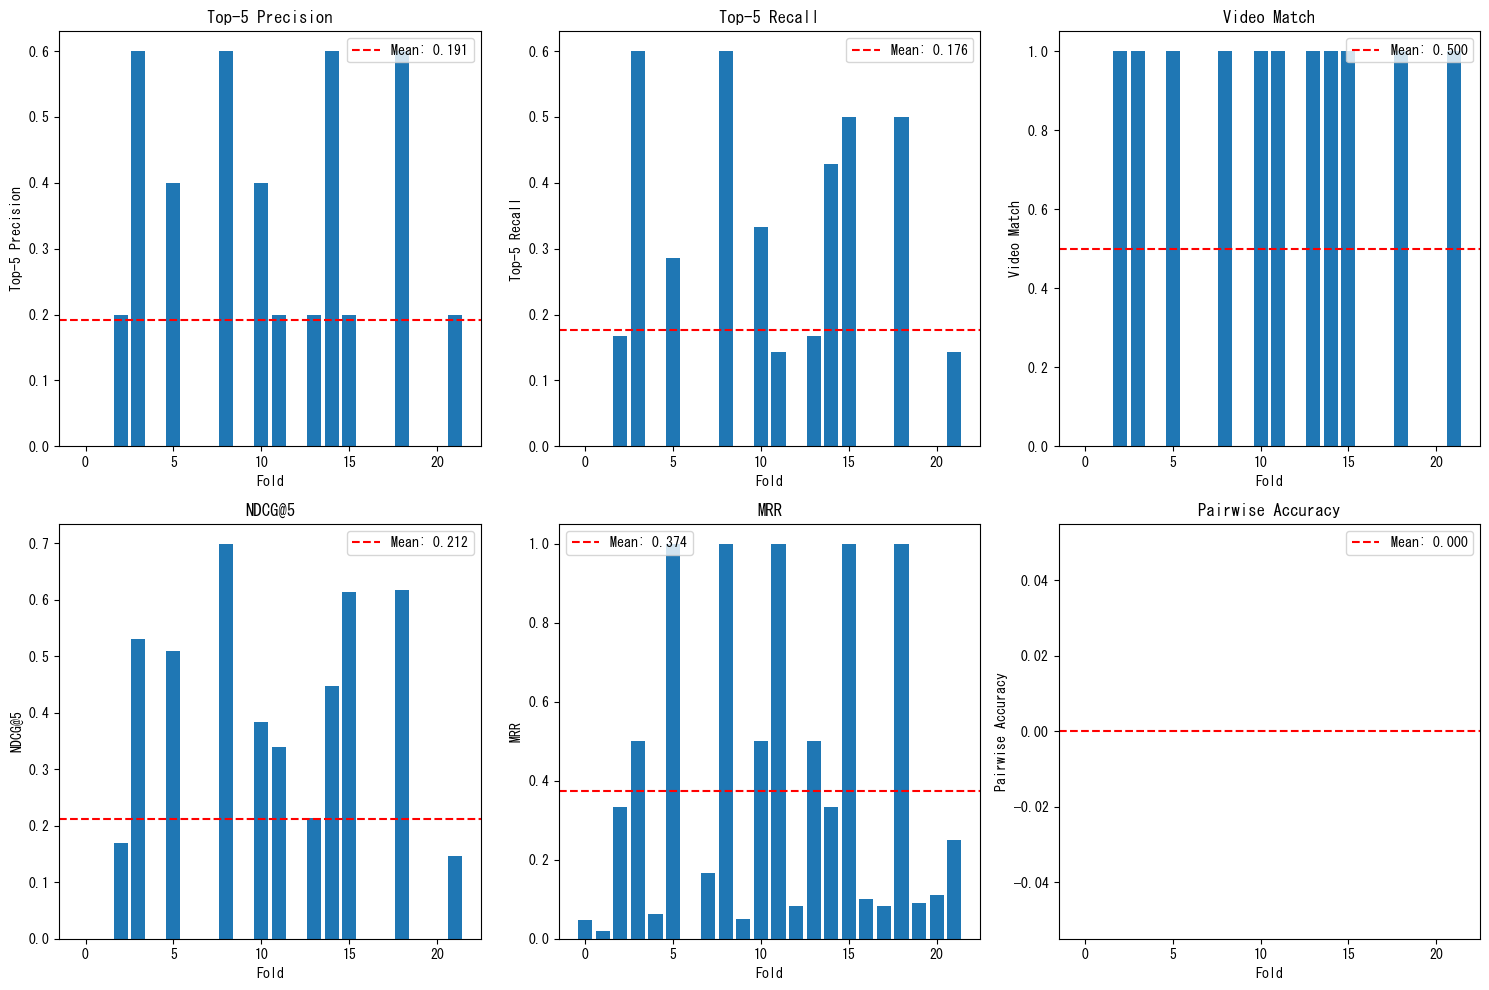

In [12]:
# 結果の可視化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = [
    ('top5_precision', 'Top-5 Precision'),
    ('top5_recall', 'Top-5 Recall'),
    ('video_match', 'Video Match'),
    ('ndcg_at_5', 'NDCG@5'),
    ('mrr', 'MRR'),
    ('pairwise_acc', 'Pairwise Accuracy'),
]

for ax, (key, title) in zip(axes.flat, metrics_to_plot):
    values = cv_results[key]
    ax.bar(range(len(values)), values)
    ax.axhline(y=np.mean(values), color='r', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 10. ベースラインとの比較

In [13]:
# ベースライン（ルールベースAI）との比較
baseline_precision = 0.545  # 54.5%
baseline_video_match = 0.864  # 86.4%

model_precision = np.mean(cv_results['top5_precision'])
model_video_match = np.mean(cv_results['video_match'])

print("=" * 60)
print("Comparison with Rule-based Baseline")
print("=" * 60)
print()
print(f"{'Metric':<25} {'Baseline':<15} {'Model':<15} {'Improvement':<15}")
print("-" * 70)

improvement = (model_precision - baseline_precision) / baseline_precision * 100
print(f"{'Top-5 Precision':<25} {baseline_precision:<15.4f} {model_precision:<15.4f} {improvement:+.1f}%")

improvement_video = (model_video_match - baseline_video_match) / baseline_video_match * 100
print(f"{'Video Match Rate':<25} {baseline_video_match:<15.4f} {model_video_match:<15.4f} {improvement_video:+.1f}%")

Comparison with Rule-based Baseline

Metric                    Baseline        Model           Improvement    
----------------------------------------------------------------------
Top-5 Precision           0.5450          0.1909          -65.0%
Video Match Rate          0.8640          0.5000          -42.1%


## 11. 最終モデルの保存

In [14]:
# 全データで学習した最終モデルを保存
print("Training final model on all data...")

all_pairs, _ = dataset.generate_pairwise_samples()
final_dataset = PairwiseBatchDataset(all_pairs)
final_loader = DataLoader(final_dataset, batch_size=config.batch_size, shuffle=True)

final_model = PairwiseRanker(config.input_dim, config.hidden_dims, config.dropout)
final_trainer = Trainer(final_model, config)
final_history = final_trainer.fit(final_loader, num_epochs=config.num_epochs, verbose=True)

# 保存
output_dir = config.output_dir
output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = output_dir / 'pairwise_ranker_final.pt'
final_trainer.save_checkpoint(checkpoint_path)

# CV結果もCSVに保存
results_df = pd.DataFrame(cv_results)
results_df.to_csv(output_dir / 'lovo_cv_results.csv', index=False)
print(f"CV results saved to {output_dir / 'lovo_cv_results.csv'}")

Training final model on all data...
Generated 1280 pairwise samples from 22 videos


Loss=0.1719, Acc=0.9414:  70%|███████   | 70/100 [00:11<00:04,  6.25it/s]


Early stopping at epoch 71
Checkpoint saved to C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\ranking_model\outputs\pairwise_ranker_final.pt
CV results saved to C:\Users\ykita\ROP_AI_project\ROP_project\bestimage_validation\ranking_model\outputs\lovo_cv_results.csv


In [15]:
# サマリー
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"\nModel: {config.input_dim} -> {config.hidden_dims} -> 1")
print(f"Loss: Margin Ranking Loss (margin={config.margin})")
print(f"\nLOVO CV Results:")
print(f"  Top-5 Precision: {np.mean(cv_results['top5_precision']):.4f} ± {np.std(cv_results['top5_precision']):.4f}")
print(f"  Video Match Rate: {np.mean(cv_results['video_match']):.4f}")
print(f"\nBaseline: 0.545")
print(f"Improvement: {(np.mean(cv_results['top5_precision']) - 0.545) / 0.545 * 100:+.1f}%")

TRAINING SUMMARY

Model: 15 -> [64, 32, 16] -> 1
Loss: Margin Ranking Loss (margin=1.0)

LOVO CV Results:
  Top-5 Precision: 0.1909 ± 0.2294
  Video Match Rate: 0.5000

Baseline: 0.545
Improvement: -65.0%
